In [142]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [143]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fasterrcnn_resnet50_fpn(num_classes=5)
model.load_state_dict(torch.load("best_model.pth"))

model.to(device)
model.eval()

print("Damage model loaded")

C:\Users\HP\AppData\Local\Temp\ipykernel_7064\61691267.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Damage model loaded


In [144]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [145]:
img_path = r"C:\Users\HP\Desktop\desktop\OPEN LAB\OPENLAB_PROJECT\data\data2\train\Fraud\439.jpg"

image = Image.open(img_path).convert("RGB")

img_tensor = transform(image).to(device)

In [146]:
with torch.no_grad():
    prediction = model([img_tensor])[0]

(np.float64(-0.5), np.float64(1265.5), np.float64(948.5), np.float64(-0.5))

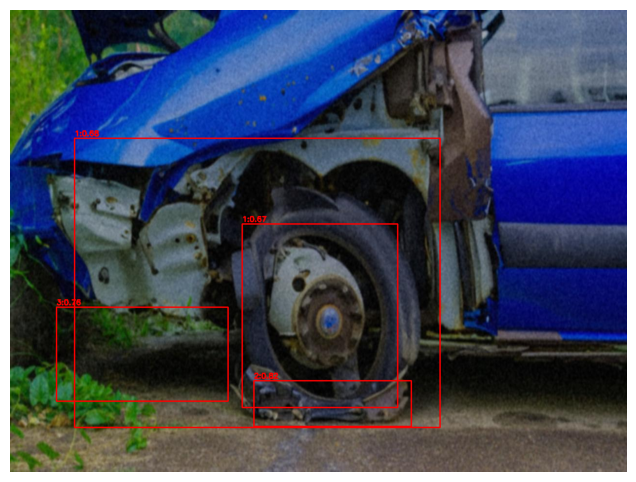

In [147]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

boxes = prediction["boxes"].cpu().numpy()
labels = prediction["labels"].cpu().numpy()
scores = prediction["scores"].cpu().numpy()

threshold = 0.5

for box, label, score in zip(boxes, labels, scores):

    if score < threshold:
        continue

    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2.putText(img, f"{label}:{score:.2f}", (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")

In [148]:
def extract_features(pred, image_shape, score_threshold= 0.5249):

    h, w = image_shape
    image_area = h * w

    boxes = pred["boxes"].cpu().numpy()
    labels = pred["labels"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()

    valid = scores > score_threshold
    boxes = boxes[valid]
    labels = labels[valid]
    scores = scores[valid]

    num_detections = len(boxes)

    if num_detections == 0:
        return [0]*13

    box_areas = []

    class_counts = [0,0,0,0]

    for box, label in zip(boxes, labels):

        x1,y1,x2,y2 = box
        area = (x2-x1)*(y2-y1)

        box_areas.append(area/image_area)

        if label <= 4:
            class_counts[label-1] += 1

    box_areas = np.array(box_areas)

    total_damage_area_ratio = np.sum(box_areas)
    avg_box_area_ratio = np.mean(box_areas)
    max_box_area_ratio = np.max(box_areas)
    min_box_area_ratio = np.min(box_areas)
    var_box_area_ratio = np.var(box_areas)

    damage_density = num_detections / image_area

    class_probs = np.array(class_counts) / np.sum(class_counts)
    class_entropy = -np.sum(class_probs * np.log(class_probs + 1e-6))

    mean_confidence = np.mean(scores)

    return [
        num_detections,
        total_damage_area_ratio,
        avg_box_area_ratio,
        max_box_area_ratio,
        min_box_area_ratio,
        var_box_area_ratio,
        damage_density,
        class_counts[0],
        class_counts[1],
        class_counts[2],
        class_counts[3],
        class_entropy,
        mean_confidence
    ]

In [149]:
features = extract_features(
    prediction,
    image_shape=image.size[::-1]
)

print("Extracted Features:")
print(features)

Extracted Features:
[4, np.float32(0.5527851), np.float32(0.13819627), np.float32(0.37076545), np.float32(0.025288366), np.float32(0.018735128), 3.3293547544018234e-06, 2, 1, 1, 0, np.float64(1.0397177708449181), np.float32(0.72982776)]


In [150]:
import joblib

fraud_model = joblib.load("fraud_rf_model.pkl")

print("Fraud model loaded")

Fraud model loaded


In [151]:
import pandas as pd

feature_columns = [
"num_detections",
"total_damage_area_ratio",
"avg_box_area_ratio",
"max_box_area_ratio",
"min_box_area_ratio",
"var_box_area_ratio",
"damage_density",
"class_1_count",
"class_2_count",
"class_3_count",
"class_4_count",
"class_entropy",
"mean_confidence"
]

df = pd.DataFrame([features], columns=feature_columns)

In [152]:
df = pd.DataFrame([features], columns=feature_columns)

fraud_prob = fraud_model.predict_proba(df)[0][1]

print("Fraud probability:", fraud_prob)

Fraud probability: 0.36666666666666664


In [153]:
threshold = 0.20

if fraud_prob >= threshold:
    result = "Fraudulent Claim"
else:
    result = "Normal Claim"

print("Fraud probability:", fraud_prob)
print("Decision:", result)

Fraud probability: 0.36666666666666664
Decision: Fraudulent Claim


In [154]:
damage_ratio = features[1]

if damage_ratio < 0.05:
    severity = "Minor Damage"

elif damage_ratio < 0.20:
    severity = "Moderate Damage"

else:
    severity = "Severe Damage"

print("Damage Severity:", severity)

Damage Severity: Severe Damage


In [155]:
dent_cost = 200
scratch_cost = 150
broken_cost = 600
paint_cost = 300

cost = (
features[3]*dent_cost +
features[4]*scratch_cost +
features[5]*broken_cost +
features[6]*paint_cost
)

print("Estimated Repair Cost: $", cost)

Estimated Repair Cost: $ 89.18842
